In [1]:
!git clone https://github.com/Exploration-Lab/CS780-OBELIX
%cd CS780-OBELIX

!pip install -r requirements.txt
!pip install gymnasium

Cloning into 'CS780-OBELIX'...
remote: Enumerating objects: 32, done.
remote: Counting objects: 100% (9/9), done.
remote: Compressing objects: 100% (5/5), done.
remote: Total 32 (delta 6), reused 4 (delta 4), pack-reused 23 (from 1)
Receiving objects: 100% (32/32), 1000.60 KiB | 18.88 MiB/s, done.
Resolving deltas: 100% (8/8), done.
/content/CS780-OBELIX


In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import os
import random
BASE_PATH = "/content/drive/MyDrive/obelix_ddqn7"
LOG_PATH = os.path.join(BASE_PATH, "training_log.txt")
BUFFER_PATH = os.path.join(BASE_PATH, "buffer.pkl")
os.makedirs(BASE_PATH, exist_ok=True)

FULL_PATH = os.path.join(BASE_PATH, "ddqn_full.pth")
WEIGHTS_PATH = os.path.join(BASE_PATH, "weights.pth")

In [4]:
import gymnasium as gym
from gymnasium import spaces
import numpy as np
from obelix import OBELIX

ACTIONS = ["L45","L22","FW","R22","R45"]

class ObelixEnv(gym.Env):
    def __init__(self, difficulty=1):
        super().__init__()

        # ✅ Single observation (18 dims)
        self.observation_space = spaces.Box(0, 1, (18,), dtype=np.float32)
        self.action_space = spaces.Discrete(5)

        self.difficulty = difficulty

    def reset(self, seed=None, options=None):

        self.env = OBELIX(
            difficulty=self.difficulty,
            max_steps=1000,
            scaling_factor=5,
            arena_size=500,
            wall_obstacles=True
        )

        obs = self.env.reset().astype(np.float32)

        return obs, {}

    def step(self, action):

        action_str = ACTIONS[action]
        obs, reward, done = self.env.step(action_str, render=False)

        obs = obs.astype(np.float32)

        return obs, reward, done, False, {}

In [5]:
def log_training(step, episode, reward, eps, loss):

    line = f"{step},{episode},{reward:.2f},{eps:.4f},{loss:.6f}\n"

    # create file with header if not exists
    if not os.path.exists(LOG_PATH):
        with open(LOG_PATH, "w") as f:
            f.write("steps,episode,reward,epsilon,loss\n")

    # append log
    with open(LOG_PATH, "a") as f:
        f.write(line)

In [6]:
import torch
import torch.nn as nn


class QNet(nn.Module):
    def __init__(self):
        super().__init__()

        self.net = nn.Sequential(
            nn.Linear(18, 128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, 5)
        )

    def forward(self, x):
        return self.net(x)

In [7]:
class PERBuffer:
    def __init__(self, size=300000, alpha=0.4):
        self.buffer = []
        self.priorities = []
        self.max_size = size
        self.alpha = alpha
        self.pos = 0

    def add(self, transition, td_error=None):

        if td_error is None:
            max_prio = max(self.priorities, default=1.0)
            priority = max_prio
        else:
            priority = (abs(td_error)+1e-5)**self.alpha

        if len(self.buffer) < self.max_size:
            self.buffer.append(transition)
            self.priorities.append(priority)
        else:
            self.buffer[self.pos] = transition
            self.priorities[self.pos] = priority
            self.pos = (self.pos+1)%self.max_size

    def sample(self, batch_size, beta=0.4):

        probs = np.array(self.priorities, dtype=np.float32)
        probs_sum = probs.sum()

        if probs_sum == 0:
            probs = np.ones_like(probs) / len(probs)
        else:
            probs /= probs_sum

        idx = np.random.choice(len(self.buffer), batch_size, p=probs)
        samples = [self.buffer[i] for i in idx]

        weights = (len(self.buffer)*probs[idx])**(-beta)
        weights /= weights.max()

        return samples, idx, torch.tensor(weights, dtype=torch.float32)

    def update(self, idx, td):
        for i, t in zip(idx, td):
            td_clipped = np.clip(abs(t), 0, 5)
            self.priorities[i] = (td_clipped + 1e-5)**self.alpha

In [8]:
import torch.optim as optim

import pickle
class Agent:
    def __init__(self):

        self.device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

        self.q = QNet().to(self.device)
        self.target = QNet().to(self.device)
        self.target.load_state_dict(self.q.state_dict())

        self.opt = optim.Adam(self.q.parameters(), lr=5e-5)

        self.buffer = PERBuffer()

        self.gamma = 0.99
        self.batch_size = 128

        # ✅ Correct epsilon schedule
        self.eps = 1.0
        self.eps_min = 0.008
        self.eps_decay_steps = 1000000

        self.steps = 0
        self.beta = 0.4
        self.beta_increment = 1e-6

    def act(self, state):
        if random.random() < self.eps:
            return random.randint(0,4)

        state = torch.FloatTensor(state).unsqueeze(0).to(self.device)

        with torch.no_grad():
            return self.q(state).argmax().item()

    def train(self):

        if len(self.buffer.buffer) < self.batch_size:
            return 0.0

        # 🔥 beta annealing
        self.beta = min(1.0, self.beta + self.beta_increment)
        samples, idx, w = self.buffer.sample(self.batch_size, beta=self.beta)

        s,a,r,s2,d = zip(*samples)

        s = torch.FloatTensor(np.array(s)).to(self.device)
        s2 = torch.FloatTensor(np.array(s2)).to(self.device)
        r = torch.FloatTensor(np.array(r)).to(self.device)
        d = torch.FloatTensor(np.array(d, dtype=np.float32)).to(self.device)
        a = torch.LongTensor(np.array(a)).to(self.device)
        w = w.to(self.device)

        q = self.q(s).gather(1,a.unsqueeze(1)).squeeze()

        with torch.no_grad():
            next_actions = self.q(s2).argmax(1)

            next_q = self.target(s2).gather(1, next_actions.unsqueeze(1)).squeeze()

            target = r + self.gamma * next_q * (1 - d)

        td = target - q

        loss = (w * torch.nn.functional.smooth_l1_loss(q, target, reduction='none')).mean()

        self.opt.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(self.q.parameters(), 1.0)
        self.opt.step()

        tau = 0.005
        for t_param, param in zip(self.target.parameters(), self.q.parameters()):
            t_param.data.copy_(tau * param.data + (1 - tau) * t_param.data)

        self.buffer.update(idx, td.detach().cpu().numpy())

        return loss.item()


    def save(self):

        # 🔥 find next available version
        idx = 1
        while True:
            full_path = os.path.join(BASE_PATH, f"ddqn_full_{idx}.pth")
            weights_path = os.path.join(BASE_PATH, f"weights_{idx}.pth")
            buffer_path = os.path.join(BASE_PATH, f"buffer_{idx}.pkl")

            if not os.path.exists(full_path):
                break
            idx += 1

        # 🔥 save full agent
        torch.save({
            "q": self.q.state_dict(),
            "target": self.target.state_dict(),
            "opt": self.opt.state_dict(),
            "eps": self.eps,
            "steps": self.steps
        }, full_path)

        # 🔥 save weights
        torch.save(self.q.state_dict(), weights_path)

        # 🔥 save buffer
        with open(buffer_path, "wb") as f:
            pickle.dump({
                "buffer": self.buffer.buffer,
                "priorities": self.buffer.priorities,
                "pos": self.buffer.pos
            }, f)

        print(f"💾 Saved version {idx}")

    def load(self, version=None):

        # 🔥 find latest version if not specified
        if version is None:
            files = [f for f in os.listdir(BASE_PATH) if f.startswith("ddqn_full_")]

            if not files:
                print("🆕 No saved models found.")
                return False

            # extract version numbers
            versions = [int(f.split("_")[-1].split(".")[0]) for f in files]
            version = max(versions)

        # 🔥 build paths
        full_path = os.path.join(BASE_PATH, f"ddqn_full_{version}.pth")
        buffer_path = os.path.join(BASE_PATH, f"buffer_{version}.pkl")

        if not os.path.exists(full_path):
            print(f"❌ File not found: {full_path}")
            return False

        # 🔥 load model
        ck = torch.load(full_path, map_location=self.device)

        self.q.load_state_dict(ck["q"])
        self.target.load_state_dict(ck["target"])
        self.opt.load_state_dict(ck["opt"])
        self.eps = ck["eps"]
        self.steps = ck.get("steps", 0)

        print(f"✅ Loaded version {version} | Steps: {self.steps} | Eps: {self.eps:.3f}")

        # 🔥 load matching buffer
        if os.path.exists(buffer_path):
            with open(buffer_path, "rb") as f:
                data = pickle.load(f)

            self.buffer.buffer = data["buffer"]
            self.buffer.priorities = data["priorities"]
            self.buffer.pos = data["pos"]

            print(f"✅ Buffer loaded: {len(self.buffer.buffer)} samples")
        else:
            print("⚠️ No buffer found for this version")

        return True

In [9]:
class Callback:
    def __init__(self, freq=200):
        self.freq = freq
        self.best = 0

    def __call__(self, agent, ep, reward):

        if ep>0 and ep % self.freq == 0:
            print("💾 Saving checkpoint...")
            agent.save()

        if reward > self.best:
            self.best = reward
            torch.save(agent.q.state_dict(), WEIGHTS_PATH)
            print("🔥 Best model saved:", reward)

In [10]:
def train_more(episodes=20):

    env = ObelixEnv()
    agent = Agent()
    agent.load()

    cb = Callback()

    last_loss = 0

    for ep in range(episodes):

        # ✅ correct difficulties
        env.difficulty = random.choice([0,2,3])

        state, _ = env.reset()
        total_reward = 0

        for t in range(500):

            action = agent.act(state)

            next_state, reward, done, _, _ = env.step(action)

            # ✅ safer reward scaling
            reward = reward

            with torch.no_grad():
                s_t = torch.FloatTensor(state).unsqueeze(0).to(agent.device)
                s2_t = torch.FloatTensor(next_state).unsqueeze(0).to(agent.device)

                q_val = agent.q(s_t)[0, action]

                next_action = agent.q(s2_t).argmax(1)
                next_q = agent.target(s2_t)[0, next_action]

                target = reward + agent.gamma * next_q * (1 - done)

                td_error = abs((target - q_val).item())

            agent.buffer.add((state, action, reward, next_state, done), td_error=td_error)

            agent.steps += 1

            loss = agent.train()
            if loss is not None:
                last_loss = loss

            state = next_state
            total_reward += reward

            # step-based epsilon (correct)
            agent.eps = max(
                agent.eps_min,
                1 - (agent.steps / agent.eps_decay_steps) * (1 - agent.eps_min)
            )

            if done:
                break
        if ep % 5 == 0:
            print(
                f"Ep {ep:03d} | "
                f"Reward {total_reward:8.2f} | "
                f"Eps {agent.eps:.3f} | "
                f"Loss {last_loss:8.4f} | "
                f"Steps {agent.steps:6d}"
            )

            # 🔥 log here if needed

            log_training(agent.steps, ep, total_reward, agent.eps, last_loss)

        cb(agent, ep, total_reward)

    print("\n💾 Saving after run...\n")
    agent.save()

    return agent

In [11]:
agent = train_more(600)

✅ Loaded version 7 | Steps: 691295 | Eps: 0.314
✅ Buffer loaded: 300000 samples
Ep 000 | Reward  -469.00 | Eps 0.314 | Loss 161.5555 | Steps 691795
Ep 005 | Reward  -474.00 | Eps 0.311 | Loss  58.7138 | Steps 694295
Ep 010 | Reward  -471.00 | Eps 0.309 | Loss 254.4699 | Steps 696795
Ep 015 | Reward -3877.00 | Eps 0.306 | Loss  36.7580 | Steps 699295
Ep 020 | Reward  -474.00 | Eps 0.304 | Loss 244.0290 | Steps 701795
Ep 025 | Reward  -484.00 | Eps 0.301 | Loss 274.5801 | Steps 704295
Ep 030 | Reward  -371.00 | Eps 0.299 | Loss  41.5623 | Steps 706795
Ep 035 | Reward  -481.00 | Eps 0.296 | Loss 173.9417 | Steps 709295
Ep 040 | Reward  -470.00 | Eps 0.294 | Loss 147.4315 | Steps 711795
Ep 045 | Reward -7267.00 | Eps 0.291 | Loss   0.4008 | Steps 714295
Ep 050 | Reward -3370.00 | Eps 0.289 | Loss 199.1140 | Steps 716795
Ep 055 | Reward  -475.00 | Eps 0.286 | Loss 181.0179 | Steps 719295
Ep 060 | Reward  -467.00 | Eps 0.284 | Loss 150.6407 | Steps 721795
Ep 065 | Reward  -472.00 | Eps 0.281

In [12]:
agent = train_more(200)

✅ Loaded version 10 | Steps: 990630 | Eps: 0.017
✅ Buffer loaded: 300000 samples
Ep 000 | Reward -17100.00 | Eps 0.017 | Loss 149.9725 | Steps 991130
Ep 005 | Reward  -474.00 | Eps 0.014 | Loss   0.1645 | Steps 993630
Ep 010 | Reward -41483.00 | Eps 0.012 | Loss   0.1542 | Steps 996130
Ep 015 | Reward  -488.00 | Eps 0.009 | Loss  46.7895 | Steps 998630
Ep 020 | Reward -8279.00 | Eps 0.008 | Loss  49.5623 | Steps 1001130
Ep 025 | Reward  -476.00 | Eps 0.008 | Loss 115.0131 | Steps 1003630
Ep 030 | Reward -27689.00 | Eps 0.008 | Loss  41.5469 | Steps 1006130
Ep 035 | Reward  -472.00 | Eps 0.008 | Loss  34.9300 | Steps 1008630
Ep 040 | Reward  -474.00 | Eps 0.008 | Loss 192.5649 | Steps 1011130
Ep 045 | Reward -12870.00 | Eps 0.008 | Loss  44.5392 | Steps 1013630
Ep 050 | Reward -3970.00 | Eps 0.008 | Loss   0.1197 | Steps 1016130
Ep 055 | Reward -26472.00 | Eps 0.008 | Loss   0.1644 | Steps 1018630
Ep 060 | Reward -17678.00 | Eps 0.008 | Loss 216.6911 | Steps 1021130
Ep 065 | Reward -556

In [ ]:

agent = train_more(2000)

🆕 No saved models found.
Ep 000 | Reward  -482.00 | Eps 1.000 | Loss   0.0864 | Steps    500
Ep 005 | Reward -12486.00 | Eps 0.997 | Loss  25.1156 | Steps   3000
Ep 010 | Reward -25684.00 | Eps 0.995 | Loss  18.6738 | Steps   5500
Ep 015 | Reward -8867.00 | Eps 0.992 | Loss  17.4389 | Steps   8000
🔥 Best model saved: 1709.0
Ep 020 | Reward -21884.00 | Eps 0.990 | Loss  13.4173 | Steps  10419
🔥 Best model saved: 1774.0
Ep 025 | Reward -20884.00 | Eps 0.987 | Loss  12.2874 | Steps  12773
Ep 030 | Reward  -474.00 | Eps 0.985 | Loss  13.0970 | Steps  15273
Ep 035 | Reward -7085.00 | Eps 0.982 | Loss  25.8021 | Steps  17773
Ep 040 | Reward  1702.00 | Eps 0.980 | Loss  53.9653 | Steps  20187
Ep 045 | Reward -1484.00 | Eps 0.977 | Loss  46.5824 | Steps  22687
Ep 050 | Reward  -373.00 | Eps 0.975 | Loss  82.4341 | Steps  25187
Ep 055 | Reward  -471.00 | Eps 0.973 | Loss  50.6150 | Steps  27687
Ep 060 | Reward -32078.00 | Eps 0.970 | Loss   0.4410 | Steps  30187
Ep 065 | Reward -4583.00 | Eps 0

In [11]:
agent = train_more(1500)

🆕 No saved models found.
Ep 000 | Reward -15486.00 | Eps 1.000 | Loss  36.0672 | Steps    500
🔥 Best model saved: -15486.0
🔥 Best model saved: -5884.0
🔥 Best model saved: -488.0
Ep 005 | Reward -5467.00 | Eps 0.997 | Loss  15.1671 | Steps   3000
🔥 Best model saved: -482.0
Ep 010 | Reward -6281.00 | Eps 0.995 | Loss  12.6184 | Steps   5500
🔥 Best model saved: 1687.0
Ep 015 | Reward  -470.00 | Eps 0.992 | Loss  22.0584 | Steps   7935
Ep 020 | Reward -1671.00 | Eps 0.990 | Loss   2.4310 | Steps  10435
Ep 025 | Reward -2676.00 | Eps 0.987 | Loss  10.6058 | Steps  12935
Ep 030 | Reward -10276.00 | Eps 0.985 | Loss  15.4895 | Steps  15435
Ep 035 | Reward  -377.00 | Eps 0.982 | Loss   8.2255 | Steps  17813
🔥 Best model saved: 1795.0
Ep 040 | Reward -8684.00 | Eps 0.980 | Loss  16.2383 | Steps  20126
Ep 045 | Reward  -481.00 | Eps 0.978 | Loss  54.2829 | Steps  22626
🔥 Best model saved: 1969.0
Ep 050 | Reward -25772.00 | Eps 0.975 | Loss  29.1979 | Steps  24782
Ep 055 | Reward -2888.00 | Eps 0

In [13]:
agent = train_more(500)

✅ Loaded version 8 | Steps: 742803 | Eps: 0.263
✅ Buffer loaded: 50000 samples
Ep 000 | Reward  -474.00 | Eps 0.263 | Loss  80.5844 | Steps 743303
Ep 005 | Reward  -472.00 | Eps 0.260 | Loss 172.2644 | Steps 745803
Ep 010 | Reward -8423.00 | Eps 0.258 | Loss 130.0222 | Steps 747956
Ep 015 | Reward  -372.00 | Eps 0.256 | Loss  64.5054 | Steps 750456
Ep 020 | Reward  -467.00 | Eps 0.253 | Loss 230.3352 | Steps 752683
Ep 025 | Reward  -368.00 | Eps 0.251 | Loss 130.0199 | Steps 755183
Ep 030 | Reward  -472.00 | Eps 0.248 | Loss 120.6370 | Steps 757683
Ep 035 | Reward  -474.00 | Eps 0.246 | Loss  47.6313 | Steps 760183
Ep 040 | Reward  -478.00 | Eps 0.243 | Loss 146.4646 | Steps 762683
Ep 045 | Reward  -469.00 | Eps 0.241 | Loss  39.4962 | Steps 765183
Ep 050 | Reward -5676.00 | Eps 0.238 | Loss 109.3934 | Steps 767683
Ep 055 | Reward  -484.00 | Eps 0.236 | Loss  30.1332 | Steps 770183
Ep 060 | Reward  -474.00 | Eps 0.233 | Loss  95.5072 | Steps 772683
Ep 065 | Reward  -472.00 | Eps 0.231 

KeyboardInterrupt: 

In [20]:
agent = train_more(1500)

❌ File not found: /content/drive/MyDrive/obelix_ddqn4/ddqn_full.pth
Ep 000 | Reward  -114.90 | Eps 1.000 | Loss   0.0296 | Steps    500
🔥 Best model saved: -114.89999999999877
🔥 Best model saved: -98.3999999999987
🔥 Best model saved: -46.700000000000415
Ep 005 | Reward   -46.90 | Eps 0.999 | Loss   0.0525 | Steps   3000
Ep 010 | Reward   -47.60 | Eps 0.997 | Loss   0.0777 | Steps   5500
Ep 015 | Reward   -86.20 | Eps 0.996 | Loss   0.1129 | Steps   8000
Ep 020 | Reward   -46.30 | Eps 0.995 | Loss   0.0347 | Steps  10500
🔥 Best model saved: -46.30000000000041
Ep 025 | Reward   -66.60 | Eps 0.994 | Loss   0.0487 | Steps  13000
Ep 030 | Reward  -134.80 | Eps 0.992 | Loss   0.1003 | Steps  15500
Ep 035 | Reward   -48.70 | Eps 0.991 | Loss   0.3240 | Steps  18000
Ep 040 | Reward   -70.10 | Eps 0.990 | Loss   0.1097 | Steps  20500
💾 Saving checkpoint...
💾 Saved version 1
Ep 045 | Reward   -46.70 | Eps 0.989 | Loss   0.1606 | Steps  23000
Ep 050 | Reward   -48.70 | Eps 0.987 | Loss   0.1609 |

In [16]:
agent = train_more(1500)

✅ Loaded version 38 | Steps: 740746 | Eps: 0.633
✅ Buffer loaded: 50000 samples
Ep 000 | Reward  -110.70 | Eps 0.632 | Loss   0.0260 | Steps 741246
🔥 Best model saved: -110.69999999999938
🔥 Best model saved: -83.0000000000003
Ep 005 | Reward  -119.70 | Eps 0.631 | Loss   0.0256 | Steps 743746
🔥 Best model saved: -47.30000000000041
🔥 Best model saved: -47.10000000000042
Ep 010 | Reward   -49.60 | Eps 0.630 | Loss   0.0324 | Steps 746246
Ep 015 | Reward   -47.60 | Eps 0.629 | Loss   0.0127 | Steps 748746
🔥 Best model saved: -45.8000000000004
🔥 Best model saved: -21.900000000000052
Ep 020 | Reward   -75.90 | Eps 0.628 | Loss   0.0228 | Steps 751008
Ep 025 | Reward   -79.60 | Eps 0.626 | Loss   0.0341 | Steps 753508
Ep 030 | Reward   -78.10 | Eps 0.625 | Loss   0.0289 | Steps 756008
Ep 035 | Reward   -94.60 | Eps 0.624 | Loss   0.0403 | Steps 758508
Ep 040 | Reward   -47.30 | Eps 0.623 | Loss   0.0447 | Steps 761008
💾 Saving checkpoint...
💾 Saved version 39
Ep 045 | Reward   -60.10 | Eps 0

In [17]:
agent = train_more(1000)

✅ Loaded version 76 | Steps: 1473372 | Eps: 0.269
✅ Buffer loaded: 50000 samples
Ep 000 | Reward   -47.60 | Eps 0.269 | Loss   0.0175 | Steps 1473872
🔥 Best model saved: -47.60000000000041
🔥 Best model saved: -15.199999999999964
Ep 005 | Reward   -46.70 | Eps 0.268 | Loss   0.0119 | Steps 1476055
Ep 010 | Reward   -70.20 | Eps 0.267 | Loss   0.0165 | Steps 1478555
Ep 015 | Reward   -52.10 | Eps 0.265 | Loss   0.0073 | Steps 1481055
Ep 020 | Reward   -56.10 | Eps 0.264 | Loss   0.0322 | Steps 1483555
Ep 025 | Reward  -194.40 | Eps 0.263 | Loss   0.0124 | Steps 1486055
Ep 030 | Reward   -47.10 | Eps 0.262 | Loss   0.0489 | Steps 1488555
Ep 035 | Reward   -45.70 | Eps 0.260 | Loss   0.0262 | Steps 1491055
🔥 Best model saved: -1.0000000000000013
Ep 040 | Reward  -174.40 | Eps 0.259 | Loss   0.0153 | Steps 1493120
💾 Saving checkpoint...
💾 Saved version 77
Ep 045 | Reward  -186.80 | Eps 0.258 | Loss   0.0489 | Steps 1495620
Ep 050 | Reward   -69.30 | Eps 0.257 | Loss   0.0228 | Steps 1498120

In [ ]:
agent = train_more(1000)

✅ Loaded model | Steps: 488023 | Eps: 0.758
✅ Buffer loaded: 50000 samples
Ep 000 | Reward -1386.70 | Eps 0.758 | Loss   0.1013 | Steps 488523
💾 Saving checkpoint...
💾 Buffer saved: 50000 samples
🔥 Best model saved: -1386.699999999999
🔥 Best model saved: -46.7000000000004
Ep 005 | Reward -1587.90 | Eps 0.756 | Loss   0.1910 | Steps 491023
Ep 010 | Reward -2206.70 | Eps 0.755 | Loss   0.1633 | Steps 493523


In [ ]:
agent = train_more(1000)

✅ Loaded model | Steps: 943817 | Eps: 0.103
Ep 000 | Reward  -687.10 | Eps 0.103 | Loss  19.0729 | Steps 944317
💾 Saving checkpoint...
🔥 Best model saved: -687.1000000000026
🔥 Best model saved: 179.79999999999987
Ep 005 | Reward   -47.00 | Eps 0.101 | Loss   6.3734 | Steps 946647
Ep 010 | Reward  -746.80 | Eps 0.098 | Loss  17.2146 | Steps 949147
Ep 015 | Reward -2407.20 | Eps 0.096 | Loss 280.6098 | Steps 951647
🔥 Best model saved: 183.50000000000006
Ep 020 | Reward  -346.90 | Eps 0.094 | Loss  43.3048 | Steps 953928
Ep 025 | Reward   192.10 | Eps 0.092 | Loss 1786.4890 | Steps 956124
🔥 Best model saved: 192.10000000000002
Ep 030 | Reward   -47.50 | Eps 0.089 | Loss  41.8879 | Steps 958624
Ep 035 | Reward -2948.50 | Eps 0.087 | Loss 2017.4989 | Steps 961124
Ep 040 | Reward  -108.70 | Eps 0.085 | Loss 101.1186 | Steps 963624
💾 Saving checkpoint...
Ep 045 | Reward  -306.90 | Eps 0.082 | Loss 300.7644 | Steps 966124
Ep 050 | Reward  -387.30 | Eps 0.080 | Loss  92.0535 | Steps 968624
Ep 0

In [ ]:
agent.save()

In [ ]:
#agent = train(episodes=500)

Ep 0 | Reward -1800.0 | Eps 1.000
💾 Saving checkpoint...
🔥 Best model saved: -1800.0
Ep 1 | Reward -3000.0 | Eps 1.000
Ep 2 | Reward -17000.0 | Eps 0.998
Ep 3 | Reward -1000.0 | Eps 0.996
🔥 Best model saved: -1000.0
Ep 4 | Reward -1000.0 | Eps 0.994
Ep 5 | Reward -13000.0 | Eps 0.992
Ep 6 | Reward -8000.0 | Eps 0.991
Ep 7 | Reward -10400.0 | Eps 0.989
Ep 8 | Reward -3400.0 | Eps 0.987
Ep 9 | Reward -972.0 | Eps 0.985
🔥 Best model saved: -972.0
Ep 10 | Reward -868.0 | Eps 0.983
🔥 Best model saved: -868.0
Ep 11 | Reward -990.0 | Eps 0.981
Ep 12 | Reward -1000.0 | Eps 0.979
Ep 13 | Reward -972.0 | Eps 0.977
Ep 14 | Reward -1000.0 | Eps 0.975
Ep 15 | Reward -972.0 | Eps 0.973
Ep 16 | Reward -25400.0 | Eps 0.972
Ep 17 | Reward -23000.0 | Eps 0.970
Ep 18 | Reward -14000.0 | Eps 0.968
Ep 19 | Reward -12200.0 | Eps 0.966
Ep 20 | Reward -12800.0 | Eps 0.964
Ep 21 | Reward -31200.0 | Eps 0.962
Ep 22 | Reward -4000.0 | Eps 0.960
Ep 23 | Reward -12200.0 | Eps 0.958
Ep 24 | Reward -1000.0 | Eps 0.9

In [ ]:





agent = train(episodes=1500)

Ep 0 | Reward -980.0 | Eps 1.000
💾 Saving checkpoint...
🔥 Best model saved: -980.0
Ep 1 | Reward -2384.0 | Eps 1.000
Ep 2 | Reward -967.0 | Eps 0.999
🔥 Best model saved: -967.0
Ep 3 | Reward -5390.0 | Eps 0.999
Ep 4 | Reward -11770.0 | Eps 0.998
Ep 5 | Reward -18200.0 | Eps 0.997
Ep 6 | Reward -1000.0 | Eps 0.997
Ep 7 | Reward -25800.0 | Eps 0.996
Ep 8 | Reward -982.0 | Eps 0.995
Ep 9 | Reward -10979.0 | Eps 0.995
Ep 10 | Reward -12572.0 | Eps 0.994
Ep 11 | Reward -39573.0 | Eps 0.993
Ep 12 | Reward -35000.0 | Eps 0.993
Ep 13 | Reward -17572.0 | Eps 0.992
Ep 14 | Reward -868.0 | Eps 0.991
🔥 Best model saved: -868.0
Ep 15 | Reward -17769.0 | Eps 0.991
Ep 16 | Reward -23384.0 | Eps 0.990
Ep 17 | Reward -15774.0 | Eps 0.989
Ep 18 | Reward -868.0 | Eps 0.989
Ep 19 | Reward -7167.0 | Eps 0.988
Ep 20 | Reward -11769.0 | Eps 0.987
Ep 21 | Reward -972.0 | Eps 0.987
Ep 22 | Reward -14368.0 | Eps 0.986
Ep 23 | Reward -8167.0 | Eps 0.985
Ep 24 | Reward -49000.0 | Eps 0.985
Ep 25 | Reward -31572.0

In [ ]:
agent = train(episodes=500)

Ep 0 | Reward -1067.0 | Eps 1.000
💾 Saving checkpoint...
🔥 Best model saved: -1067.0
Ep 1 | Reward -484.0 | Eps 1.000
🔥 Best model saved: -484.0
Ep 2 | Reward -500.0 | Eps 0.998
Ep 3 | Reward -472.0 | Eps 0.996
🔥 Best model saved: -472.0
Ep 4 | Reward -12469.0 | Eps 0.994
Ep 5 | Reward -467.0 | Eps 0.992
🔥 Best model saved: -467.0
Ep 6 | Reward -368.0 | Eps 0.990
🔥 Best model saved: -368.0
Ep 7 | Reward -3368.0 | Eps 0.988
Ep 8 | Reward -17100.0 | Eps 0.986
Ep 9 | Reward -500.0 | Eps 0.984
Ep 10 | Reward -1300.0 | Eps 0.982
Ep 11 | Reward -9267.0 | Eps 0.980
Ep 12 | Reward -16267.0 | Eps 0.978
Ep 13 | Reward -12086.0 | Eps 0.976
Ep 14 | Reward -472.0 | Eps 0.974
Ep 15 | Reward -11500.0 | Eps 0.972
Ep 16 | Reward -9267.0 | Eps 0.970
Ep 17 | Reward -7700.0 | Eps 0.968
Ep 18 | Reward -17500.0 | Eps 0.966
Ep 19 | Reward -483.0 | Eps 0.964
Ep 20 | Reward -500.0 | Eps 0.962
Ep 21 | Reward -472.0 | Eps 0.960
Ep 22 | Reward -11300.0 | Eps 0.958
Ep 23 | Reward -9687.0 | Eps 0.956
Ep 24 | Reward

KeyboardInterrupt: 

PLOTS

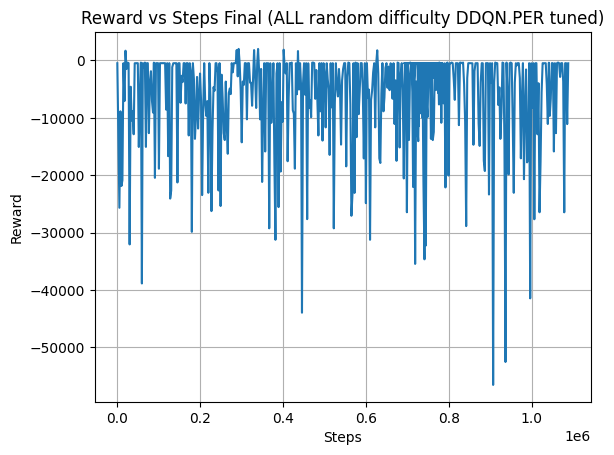

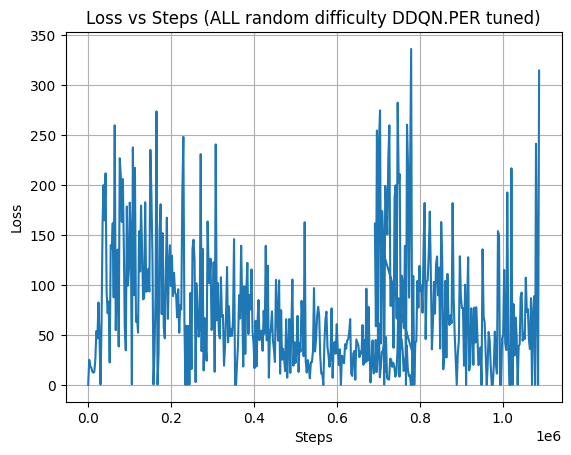

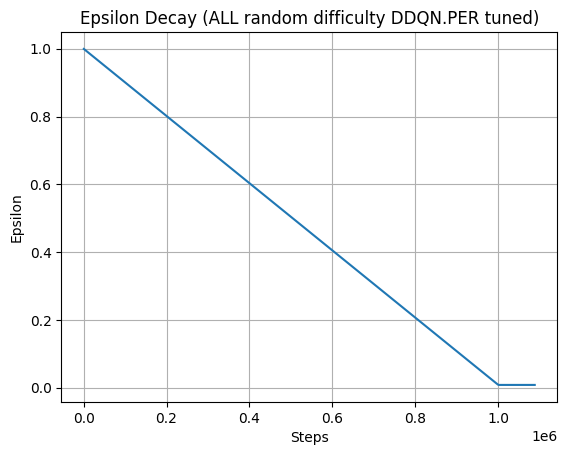

In [4]:
import pandas as pd
import os
import matplotlib.pyplot as plt

BASE_PATH = "/content/drive/MyDrive/obelix_ddqn7"
LOG_PATH = os.path.join(BASE_PATH, "training_log.txt")

# Load file
df = pd.read_csv(LOG_PATH)


# -------- Reward Plot --------
plt.figure()
plt.plot(df["steps"], df["reward"])
plt.xlabel("Steps")
plt.ylabel("Reward")
plt.title("Reward vs Steps Final (ALL random difficulty DDQN.PER tuned)")
plt.grid()
plt.show()

# -------- Loss Plot --------
plt.figure()
plt.plot(df["steps"], df["loss"])
plt.xlabel("Steps")
plt.ylabel("Loss")
plt.title("Loss vs Steps (ALL random difficulty DDQN.PER tuned)")
plt.grid()
plt.show()

# -------- Epsilon Plot --------
plt.figure()
plt.plot(df["steps"], df["epsilon"])
plt.xlabel("Steps")
plt.ylabel("Epsilon")
plt.title("Epsilon Decay (ALL random difficulty DDQN.PER tuned)")
plt.grid()
plt.show()

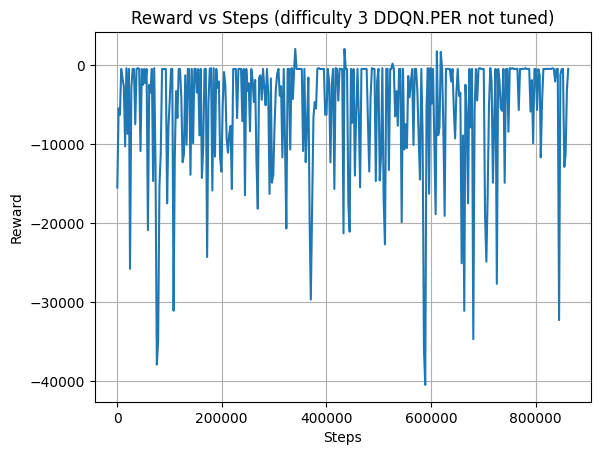

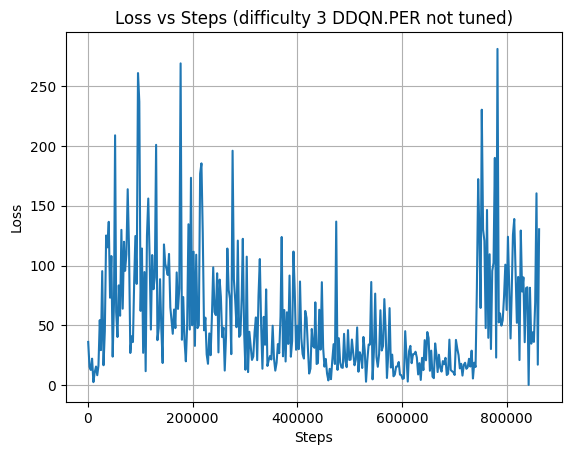

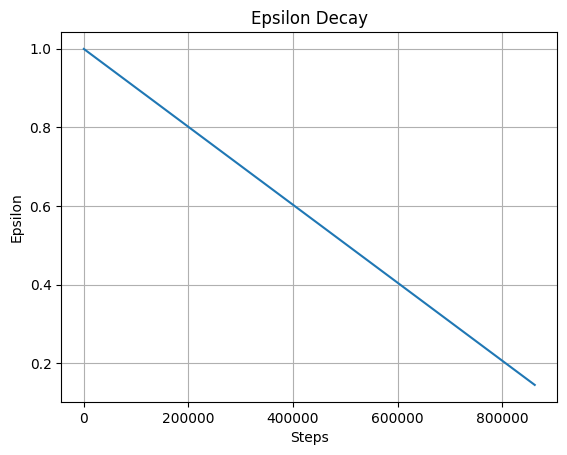

In [5]:
import pandas as pd
import os
import matplotlib.pyplot as plt

BASE_PATH = "/content/drive/MyDrive/obelix_ddqn6"
LOG_PATH = os.path.join(BASE_PATH, "training_log.txt")

# Load file
df = pd.read_csv(LOG_PATH)


# -------- Reward Plot --------
plt.figure()
plt.plot(df["steps"], df["reward"])
plt.xlabel("Steps")
plt.ylabel("Reward")
plt.title("Reward vs Steps (difficulty 3 DDQN.PER not tuned)")
plt.grid()
plt.show()

# -------- Loss Plot --------
plt.figure()
plt.plot(df["steps"], df["loss"])
plt.xlabel("Steps")
plt.ylabel("Loss")
plt.title("Loss vs Steps (difficulty 3 DDQN.PER not tuned)")
plt.grid()
plt.show()

# -------- Epsilon Plot --------
plt.figure()
plt.plot(df["steps"], df["epsilon"])
plt.xlabel("Steps")
plt.ylabel("Epsilon")
plt.title("Epsilon Decay (difficulty 3 DDQN.PER not tuned)")
plt.grid()
plt.show()

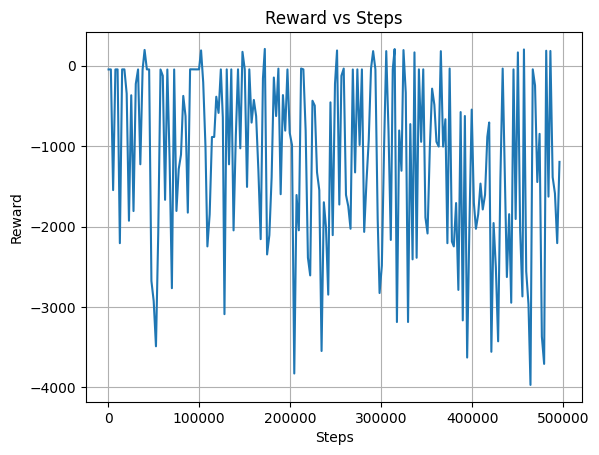

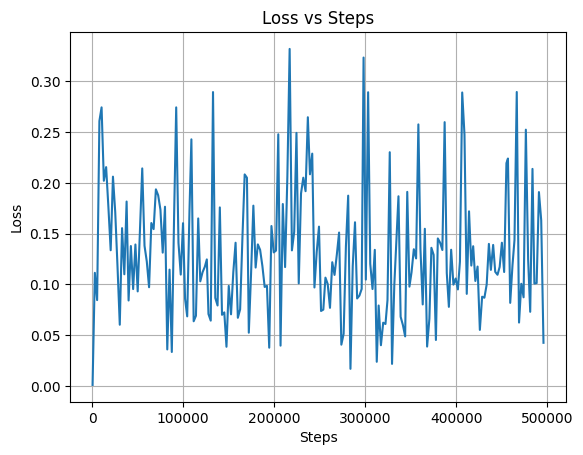

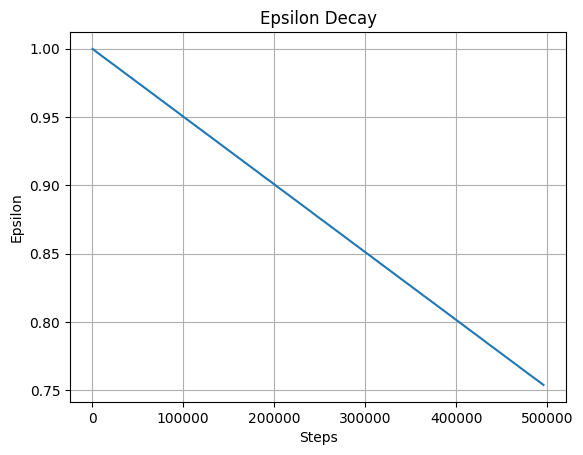

In [6]:
import pandas as pd
import os
import matplotlib.pyplot as plt

BASE_PATH = "/content/drive/MyDrive/obelix_ddqn3"
LOG_PATH = os.path.join(BASE_PATH, "training_log.txt")

# Load file
df = pd.read_csv(LOG_PATH)


# -------- Reward Plot --------
plt.figure()
plt.plot(df["steps"], df["reward"])
plt.xlabel("Steps")
plt.ylabel("Reward")
plt.title("Reward vs Steps( Some Test RUn)")
plt.grid()
plt.show()

# -------- Loss Plot --------
plt.figure()
plt.plot(df["steps"], df["loss"])
plt.xlabel("Steps")
plt.ylabel("Loss")
plt.title("Loss vs Steps(SOme test RUn)")
plt.grid()
plt.show()

# -------- Epsilon Plot --------
plt.figure()
plt.plot(df["steps"], df["epsilon"])
plt.xlabel("Steps")
plt.ylabel("Epsilon")
plt.title("Epsilon Decay(some test run)")
plt.grid()
plt.show()

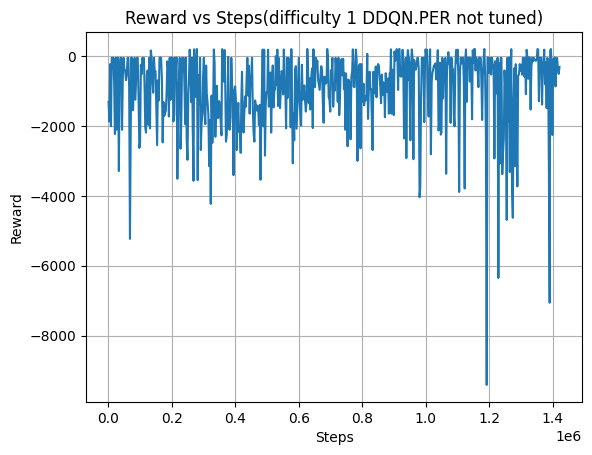

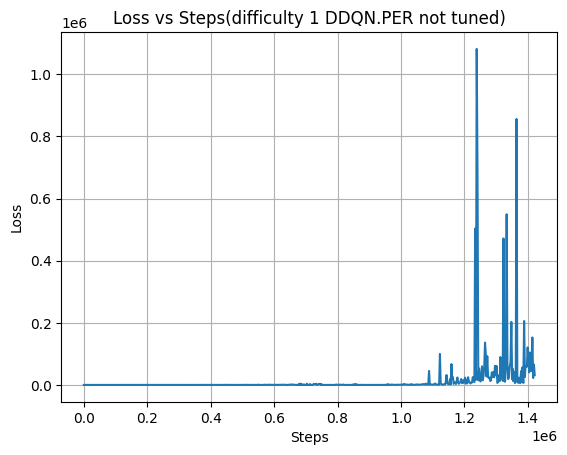

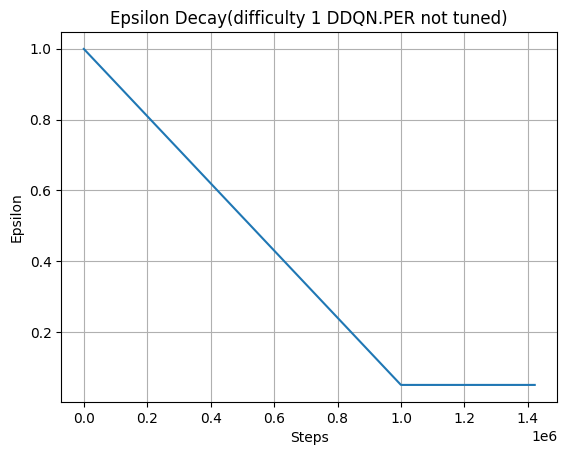

In [6]:
import pandas as pd
import os
import matplotlib.pyplot as plt

BASE_PATH = "/content/drive/MyDrive/obelix_ddqn2"
LOG_PATH = os.path.join(BASE_PATH, "training_log.txt")

# Load file
df = pd.read_csv(LOG_PATH)


# -------- Reward Plot --------
plt.figure()
plt.plot(df["steps"], df["reward"])
plt.xlabel("Steps")
plt.ylabel("Reward")
plt.title("Reward vs Steps(difficulty 1 DDQN.PER not tuned)")
plt.grid()
plt.show()

# -------- Loss Plot --------
plt.figure()
plt.plot(df["steps"], df["loss"])
plt.xlabel("Steps")
plt.ylabel("Loss")
plt.title("Loss vs Steps(difficulty 1 DDQN.PER not tuned)")
plt.grid()
plt.show()

# -------- Epsilon Plot --------
plt.figure()
plt.plot(df["steps"], df["epsilon"])
plt.xlabel("Steps")
plt.ylabel("Epsilon")
plt.title("Epsilon Decay(difficulty 1 DDQN.PER not tuned)")
plt.grid()
plt.show()

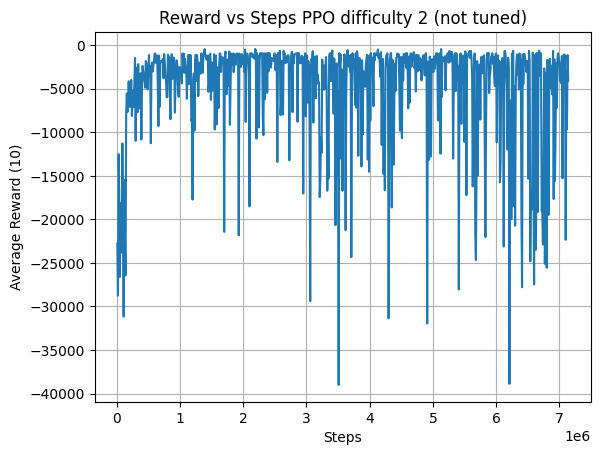

In [7]:
import pandas as pd
import os
import matplotlib.pyplot as plt

BASE_PATH = "/content/drive/MyDrive/obelix_models"
LOG_PATH = os.path.join(BASE_PATH, "training_log.txt")

# Load file
df = pd.read_csv(LOG_PATH)


# -------- Reward Plot --------
plt.figure()
plt.plot(df["steps"], df["avg_reward"])
plt.xlabel("Steps")
plt.ylabel("Average Reward (10)")
plt.title("Reward vs Steps PPO difficulty 2 (not tuned)")
plt.grid()
plt.show()


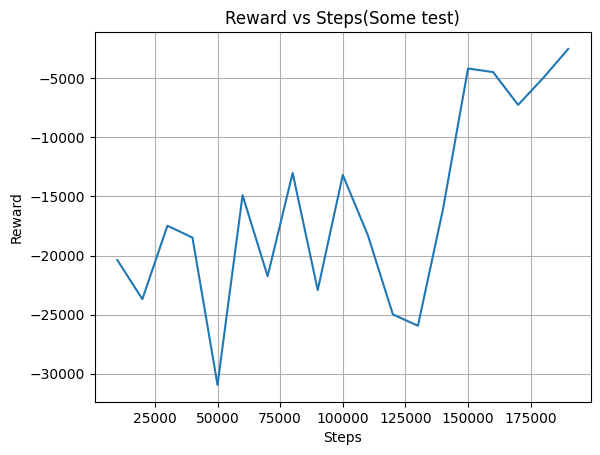

In [8]:
import pandas as pd
import os
import matplotlib.pyplot as plt

LOG_PATH = os.path.join("training_log.txt")

# Load file
df = pd.read_csv(LOG_PATH)


# -------- Reward Plot --------
plt.figure()
plt.plot(df["steps"], df["avg_reward"])
plt.xlabel("Steps")
plt.ylabel("Reward")
plt.title("Reward vs Steps(Some test)")
plt.grid()
plt.show()


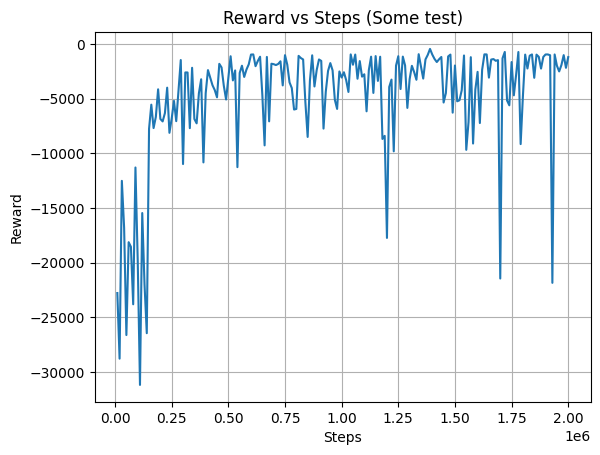

In [9]:
import pandas as pd
import os
import matplotlib.pyplot as plt

LOG_PATH = os.path.join("training_log (1).txt")

# Load file
df = pd.read_csv(LOG_PATH)


# -------- Reward Plot --------
plt.figure()
plt.plot(df["steps"], df["avg_reward"])
plt.xlabel("Steps")
plt.ylabel("Reward")
plt.title("Reward vs Steps (Some test)")
plt.grid()
plt.show()


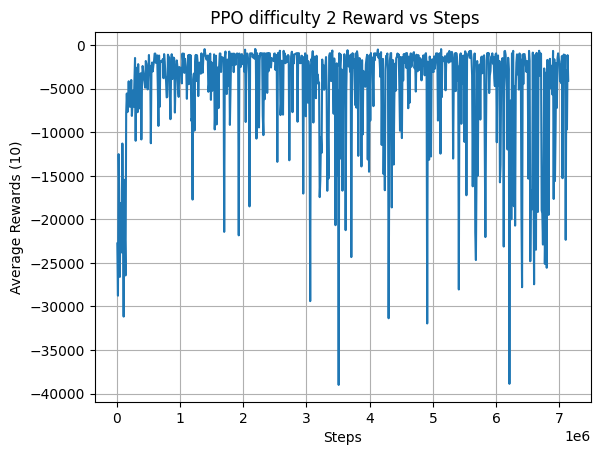

In [10]:
import pandas as pd
import os
import matplotlib.pyplot as plt

LOG_PATH = os.path.join("training_log (2).txt")

# Load file
df = pd.read_csv(LOG_PATH)


# -------- Reward Plot --------
plt.figure()
plt.plot(df["steps"], df["avg_reward"])
plt.xlabel("Steps")
plt.ylabel("Average Rewards (10)")
plt.title(" PPO difficulty 2 Reward vs Steps")
plt.grid()
plt.show()


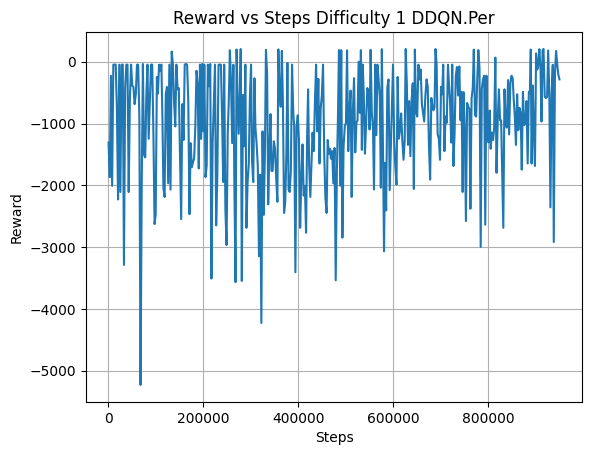

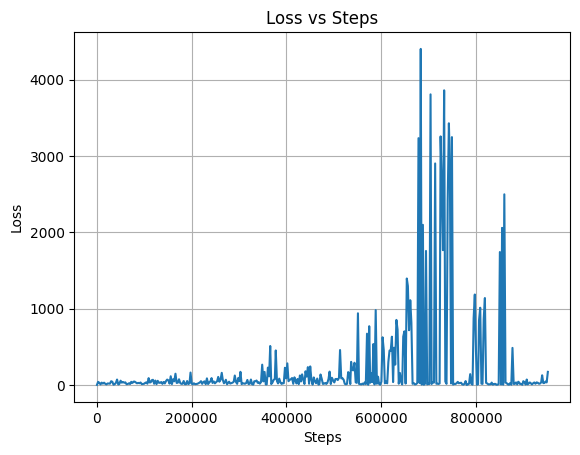

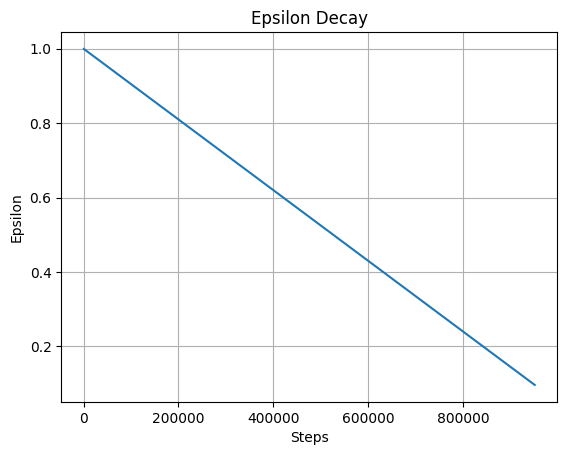

In [20]:
import pandas as pd
import os
import matplotlib.pyplot as plt

LOG_PATH = os.path.join("training_log (3).txt")

# Load file
df = pd.read_csv(LOG_PATH)


# -------- Reward Plot --------
plt.figure()
plt.plot(df["steps"], df["reward"])
plt.xlabel("Steps")
plt.ylabel("Reward")
plt.title("Reward vs Steps Difficulty 1 DDQN.Per")
plt.grid()
plt.show()

# -------- Loss Plot --------
plt.figure()
plt.plot(df["steps"], df["loss"])
plt.xlabel("Steps")
plt.ylabel("Loss")
plt.title("Loss vs Steps")
plt.grid()
plt.show()

# -------- Epsilon Plot --------
plt.figure()
plt.plot(df["steps"], df["epsilon"])
plt.xlabel("Steps")
plt.ylabel("Epsilon")
plt.title("Epsilon Decay")
plt.grid()
plt.show()

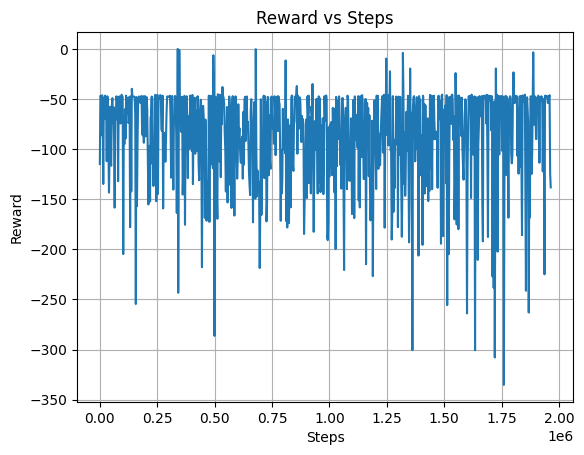

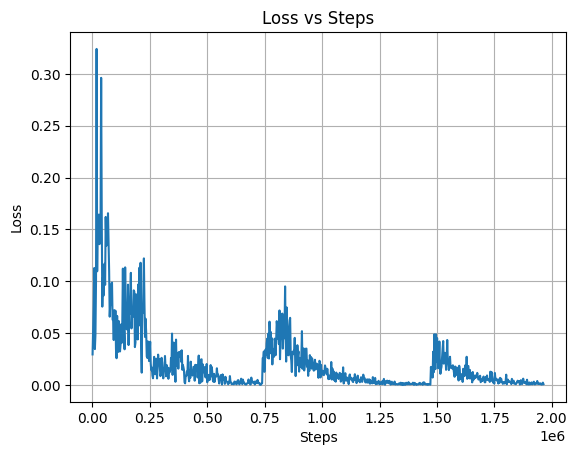

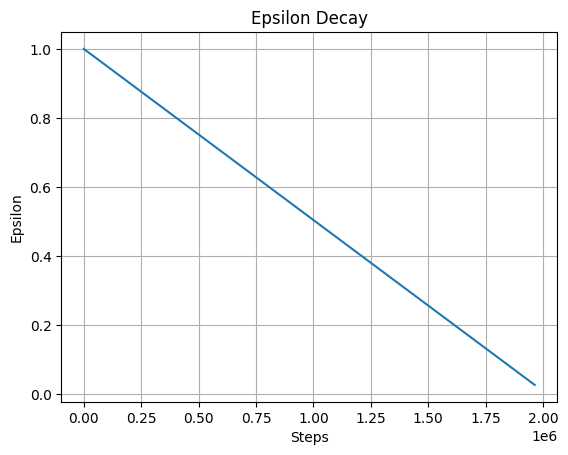

In [18]:
import pandas as pd
import os
import matplotlib.pyplot as plt

LOG_PATH = os.path.join("training_log (4) clamp and end.txt")

# Load file
df = pd.read_csv(LOG_PATH)


# -------- Reward Plot --------
plt.figure()
plt.plot(df["steps"], df["reward"])
plt.xlabel("Steps")
plt.ylabel("Reward")
plt.title("Reward vs Steps")
plt.grid()
plt.show()

# -------- Loss Plot --------
plt.figure()
plt.plot(df["steps"], df["loss"])
plt.xlabel("Steps")
plt.ylabel("Loss")
plt.title("Loss vs Steps")
plt.grid()
plt.show()

# -------- Epsilon Plot --------
plt.figure()
plt.plot(df["steps"], df["epsilon"])
plt.xlabel("Steps")
plt.ylabel("Epsilon")
plt.title("Epsilon Decay")
plt.grid()
plt.show()